<a href="https://colab.research.google.com/github/Rafinx05/ProjectMIni_CitraDigital_F1G124075/blob/main/Tugas_CitraDigital_T7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Sel 1: Instalasi Library
!apt-get install tesseract-ocr
!pip install pytesseract opencv-python matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Silakan upload gambar ijazah (bisa pilih lebih dari satu file sekaligus):")
uploaded = files.upload()

# Membuat dictionary global untuk menyimpan data setiap gambar di setiap tahapan
data_ijazah = {}
for filename in uploaded.keys():
    data_ijazah[filename] = {}
print(f"\nBerhasil memuat {len(data_ijazah)} file. Lanjut ke Sel 3.")

Silakan upload gambar ijazah (bisa pilih lebih dari satu file sekaligus):


Saving 01_HighQuality_Enhanced.jpg to 01_HighQuality_Enhanced (1).jpg
Saving 02_LowContrast.jpg to 02_LowContrast (1).jpg
Saving 03_Blurred.jpg to 03_Blurred (1).jpg
Saving 04_HighNoise.jpg to 04_HighNoise (1).jpg
Saving 05_LowResolution_Upsampled.jpg to 05_LowResolution_Upsampled (1).jpg
Saving 06_Faded_Underexposed.jpg to 06_Faded_Underexposed (1).jpg
Saving 07_ColorShift_WarmTint.jpg to 07_ColorShift_WarmTint (1).jpg
Saving 08_JPEGCompression_Artifacts.jpg to 08_JPEGCompression_Artifacts (1).jpg
Saving 09_CombinedDegradation.jpg to 09_CombinedDegradation (1).jpg

Berhasil memuat 9 file. Lanjut ke Sel 3.


In [ ]:
# ==========================================
# SEL 3: PIPELINE PRE-PROCESSING
# ==========================================
for filename, data in data_ijazah.items():
    img = cv2.imread(filename)
    if img is None:
        print(f"Gagal memuat gambar: {filename}")
        continue

    # Rotasi 90 derajat searah jarum jam (Sesuai template ijazah vertikal)
    img_rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

    # 1. STANDARDISASI UKURAN (RESIZE)
    # Paksa semua gambar menjadi ukuran standar A4 Portrait (misal: Lebar 1200 x Tinggi 1600)
    # Ini memastikan koordinat piksel akan selalu jatuh di tempat yang sama persis
    img = cv2.resize(img, (1200, 1600))

    # (Opsional) 2. CEK ORIENTASI
    # Jika gambar Anda ada yang terputar menjadi landscape (lebar > tinggi), putar kembali
    tinggi_img, lebar_img = img.shape[:2]
    if lebar_img > tinggi_img:
        # Putar 90 derajat jika gambar berbentuk landscape
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        img = cv2.resize(img, (1200, 1600)) # Resize ulang ke standar portrait

    # Setelah kode di atas, baru terapkan koordinat absolut (bukan persentase lagi)
    # Contoh koordinat (harus disesuaikan ulang sedikit dengan gambar ukuran 1200x1600 Anda)
    roi_nomor = img[1450:1550, 100:600]  # [y1:y2, x1:x2]
    roi_ttd = img[1100:1400, 200:550]    # Sesuaikan dengan lokasi Rektor

    # Grayscale & CLAHE Enhancement
    gray = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    # Simpan hasil pre-processing ke dictionary
    data['enhanced_gray'] = clahe.apply(gray)

print("Pre-processing (Rotasi & Enhancement) selesai untuk semua file.")

Pre-processing (Rotasi & Enhancement) selesai untuk semua file.


In [ ]:
# ==========================================
# SEL 4: PEMOTONGAN AREA (ROI) - PENYESUAIAN AREA NOMOR IJAZAH
# ==========================================
for filename, data in data_ijazah.items():
    # Load gambar asli
    img = cv2.imread(filename)
    if img is None:
        print(f"Gagal memuat {filename}")
        continue

    # 1. Grayscale & Enhancement
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced_gray = clahe.apply(gray)
    data['enhanced_gray'] = enhanced_gray

    H, W = enhanced_gray.shape

    # 2. Pemotongan Berorientasi Kejelasan Informasi
    # Area Nomor Ijazah diperlebar agar mencakup seluruh baris teks nomor di area atas (Y: 3% - 30%, X: 20% - 85%)
    data['roi_nomor'] = enhanced_gray[int(H * 0.70) : int(H * 0.98), int(W * 0.85) : int(W * 0.99)]
    # Area Tanda Tangan Rektor tetap dipertahankan pada posisi presisi
    data['roi_ttd'] = enhanced_gray[int(H * 0.60) : int(H * 0.92), int(W * 0.62) : int(W * 0.88)]

print("Penyesuaian area crop selesai. Silakan jalankan ulang Sel Visualisasi!")

Penyesuaian area crop selesai. Silakan jalankan ulang Sel Visualisasi!


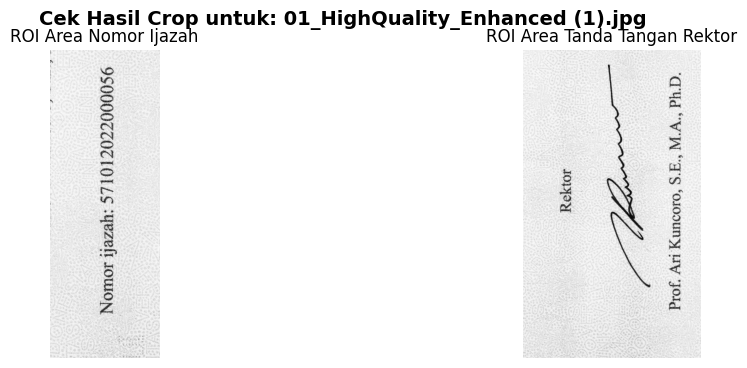

--------------------------------------------------


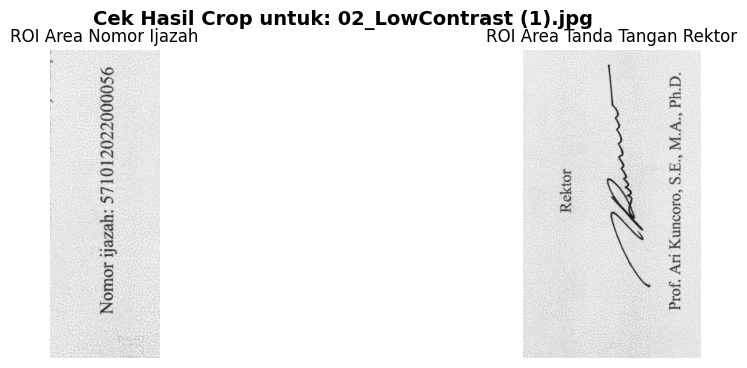

--------------------------------------------------


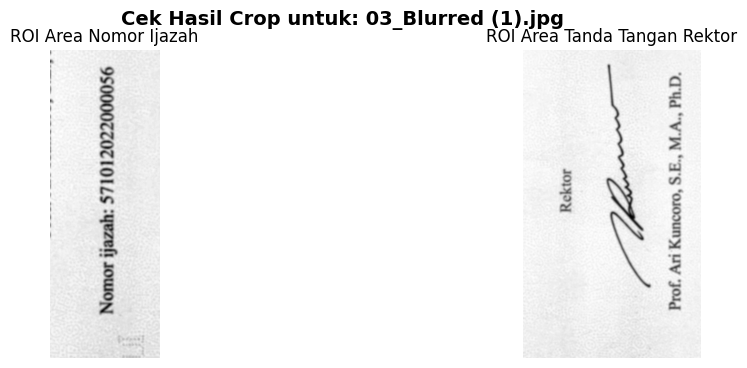

--------------------------------------------------


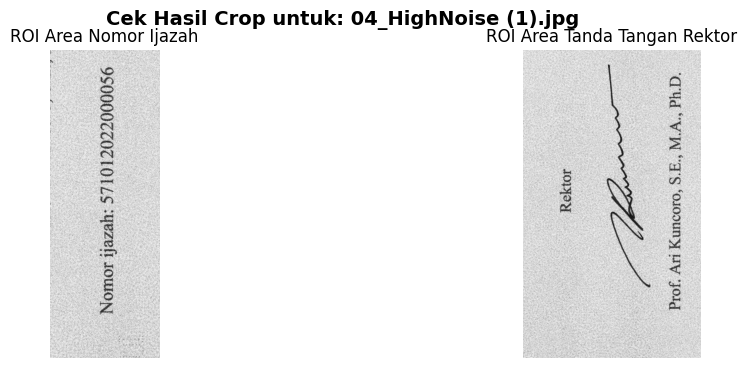

--------------------------------------------------


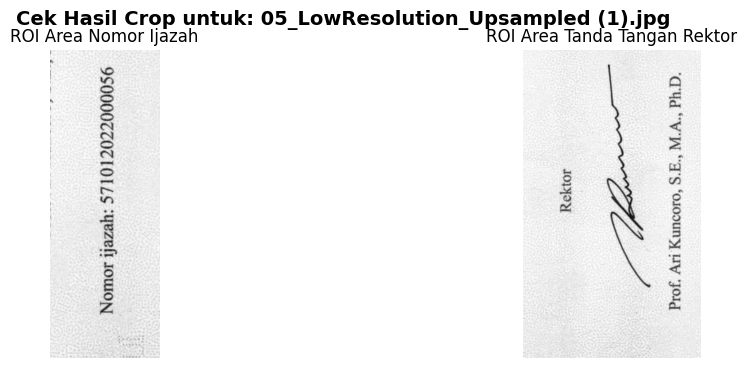

--------------------------------------------------


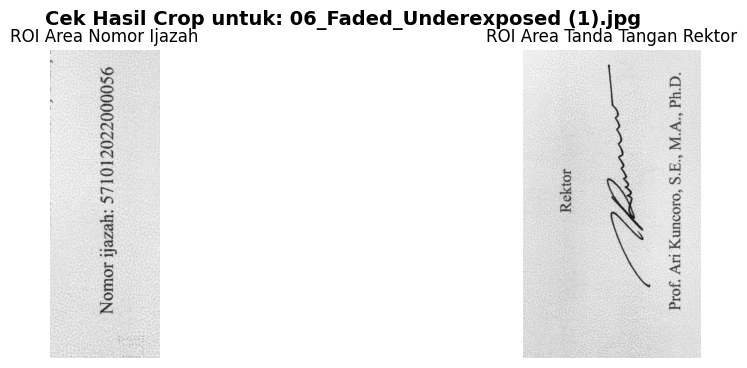

--------------------------------------------------


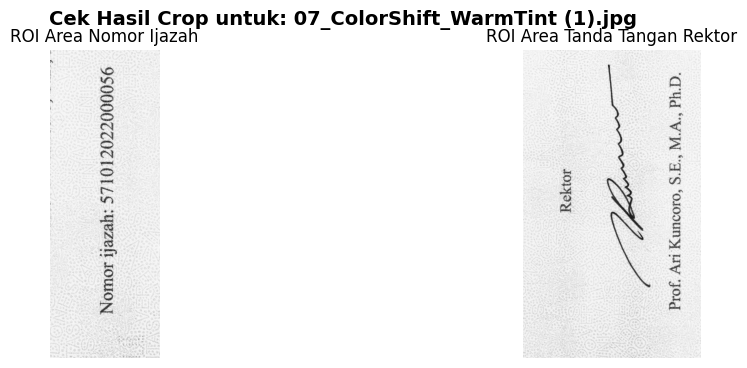

--------------------------------------------------


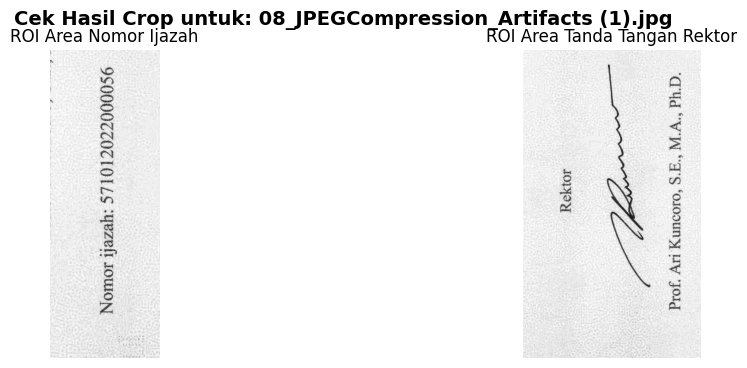

--------------------------------------------------


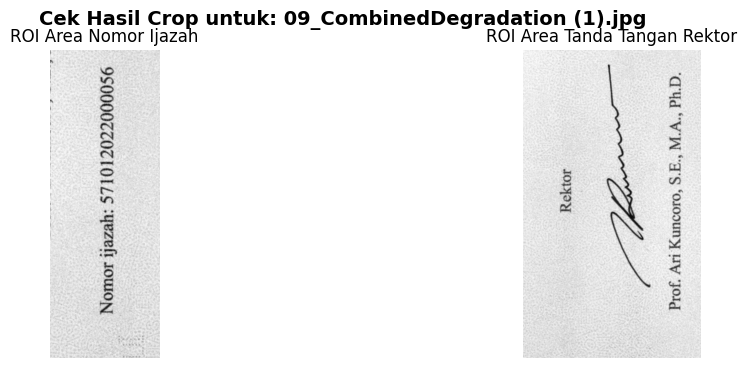

--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt

for filename, data in data_ijazah.items():
    if 'roi_nomor' not in data or 'roi_ttd' not in data:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Cek Hasil Crop untuk: {filename}", fontsize=14, fontweight='bold')

    # Menampilkan potongan area nomor ijazah
    ax[0].imshow(data['roi_nomor'], cmap='gray')
    ax[0].set_title('ROI Area Nomor Ijazah')
    ax[0].axis('off')

    # Menampilkan potongan area tanda tangan
    ax[1].imshow(data['roi_ttd'], cmap='gray')
    ax[1].set_title('ROI Area Tanda Tangan Rektor')
    ax[1].axis('off')

    plt.show()
    print("-" * 50)

In [ ]:
# ==========================================
# SEL 5: EKSTRAKSI NOMOR (OCR) - KOREKSI ARAH BACA (LEFT-TO-RIGHT)
# ==========================================
for filename, data in data_ijazah.items():
    if 'roi_nomor' not in data: continue

    roi_nomor = data['roi_nomor']

    # Putar ROI 90 derajat searah jarum jam agar teks mendatar
    roi_rotated = cv2.rotate(roi_nomor, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # Cerminkan gambar secara horizontal & vertikal agar teks dibaca dari kiri ke kanan dengan benar
    roi_flipped = cv2.flip(roi_rotated, -1)

    # 1. Pembesaran Imej (Upscaling)
    roi_nomor_large = cv2.resize(roi_flipped, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    # 2. Penyingkiran Hingar (Noise Removal)
    roi_blurred = cv2.GaussianBlur(roi_nomor_large, (3, 3), 0)

    # 3. Otsu Thresholding
    _, thresh_nomor = cv2.threshold(roi_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Ekstraksi teks menggunakan pytesseract
    custom_config = r'--oem 3 --psm 6'
    nomor_text = pytesseract.image_to_string(thresh_nomor, config=custom_config).strip()

    # Jika teks masih terbaca terbalik secara karakter, kita balikkan stringnya agar benar
    if "No" in nomor_text[::-1] or "Nomor" in nomor_text[::-1]:
        nomor_text = nomor_text[::-1]

    # Bersihkan spasi ganda
    clean_text = " ".join(nomor_text.split())

    # Simpan data
    data['thresh_nomor'] = thresh_nomor
    data['nomor_ijazah_text'] = clean_text if clean_text else "TIDAK TERBACA"

print("Perbaikan arah baca OCR selesai! Silakan jalankan ulang Sel 5 dan Sel 7.")

Perbaikan arah baca OCR selesai! Silakan jalankan ulang Sel 5 dan Sel 7.


In [ ]:
# ==========================================
# SEL 6: DETEKSI TANDA TANGAN REKTOR
# ==========================================
for filename, data in data_ijazah.items():
    if 'roi_ttd' not in data: continue

    # Otsu Thresholding (Inverse) agar tinta jadi putih
    _, thresh_ttd = cv2.threshold(data['roi_ttd'], 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morfologi untuk menyambung piksel tinta yang terputus
    kernel = np.ones((5,5), np.uint8)
    morph_ttd = cv2.morphologyEx(thresh_ttd, cv2.MORPH_CLOSE, kernel)

    # Perhitungan kepadatan piksel
    total_pixels = morph_ttd.shape[0] * morph_ttd.shape[1]
    white_pixels = cv2.countNonZero(morph_ttd)
    ink_density = (white_pixels / total_pixels) * 100

    # Simpan hasil
    data['morph_ttd'] = morph_ttd
    data['ink_density'] = ink_density
    data['status_ttd'] = "PRESENT" if ink_density > 1.5 else "ABSENT"

print("Deteksi keberadaan Tanda Tangan selesai.")

Deteksi keberadaan Tanda Tangan selesai.


In [ ]:
# ==========================================
# SEL 7: CETAK OUTPUT SESUAI FORMAT SOAL
# ==========================================
for filename, data in data_ijazah.items():
    if 'nomor_ijazah_text' not in data or 'status_ttd' not in data:
        continue

    print(f"\n[{filename}]")
    print("Input:")
    print(f"{filename}")
    print("\nOutput:")
    print(f"Nomor Ijazah : {data['nomor_ijazah_text']}")
    print(f"Tanda Tangan : {data['status_ttd']}")
    print("-" * 30)


[01_HighQuality_Enhanced (1).jpg]
Input:
01_HighQuality_Enhanced (1).jpg

Output:
Nomor Ijazah : — Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[02_LowContrast (1).jpg]
Input:
02_LowContrast (1).jpg

Output:
Nomor Ijazah : : Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[03_Blurred (1).jpg]
Input:
03_Blurred (1).jpg

Output:
Nomor Ijazah : Nomor ijazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[04_HighNoise (1).jpg]
Input:
04_HighNoise (1).jpg

Output:
Nomor Ijazah : __ Nomor ijazah: 571012022000056-
Tanda Tangan : PRESENT
------------------------------

[05_LowResolution_Upsampled (1).jpg]
Input:
05_LowResolution_Upsampled (1).jpg

Output:
Nomor Ijazah : _ Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[06_Faded_Underexposed (1).jpg]
Input:
06_Faded_Underexposed (1).jpg

Output:
Nomor Ijazah : : Nomor yazah: 571012022000056
Tanda Tangan : PRE

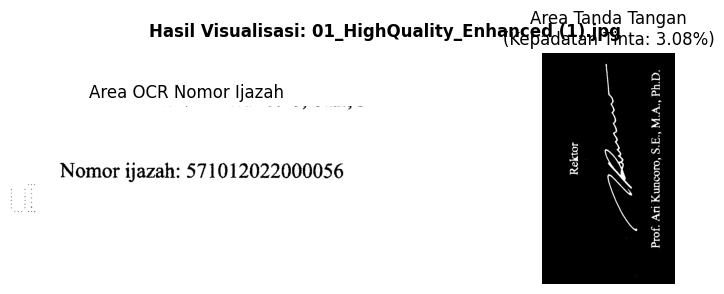

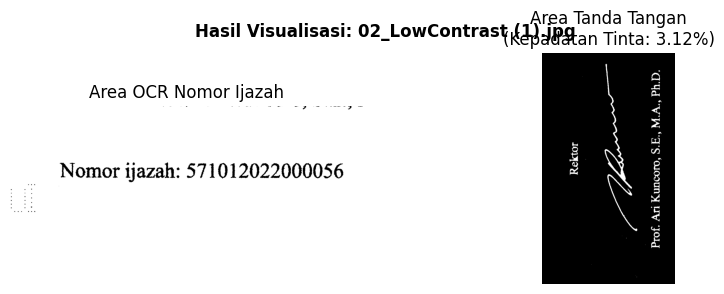

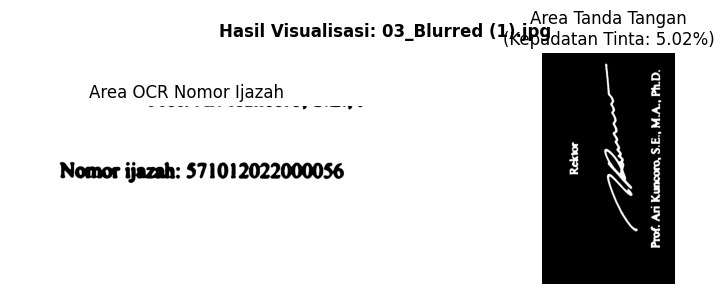

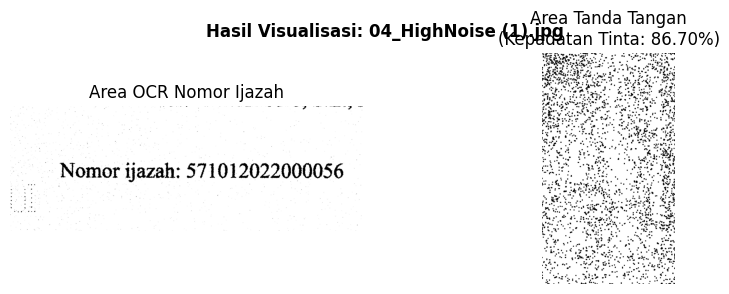

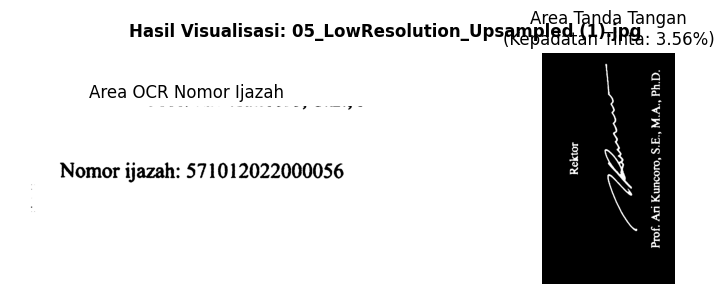

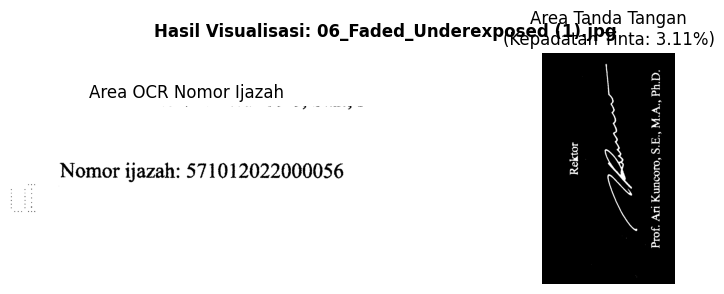

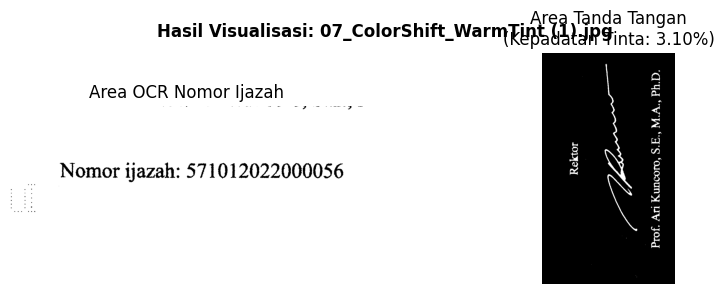

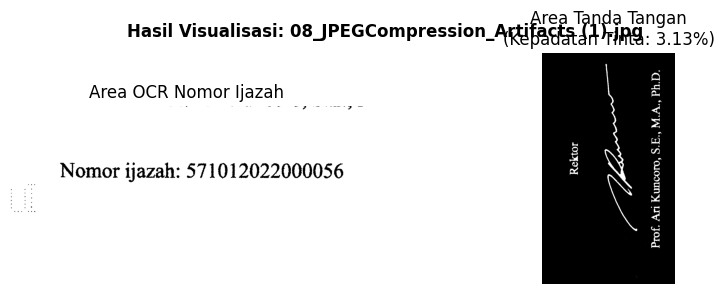

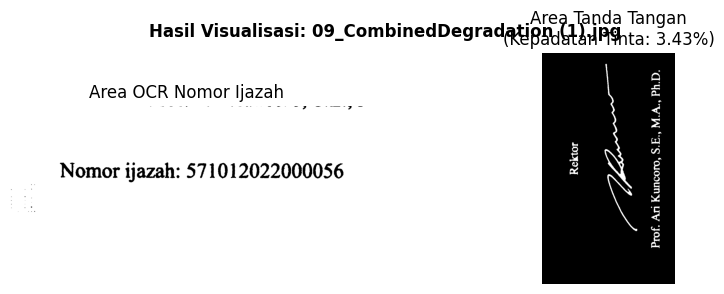

In [ ]:
# ==========================================
# SEL 8: VISUALISASI PERBANDINGAN
# ==========================================
for filename, data in data_ijazah.items():
    if 'thresh_nomor' not in data or 'morph_ttd' not in data:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(f"Hasil Visualisasi: {filename}", fontsize=12, fontweight='bold')

    ax[0].imshow(data['thresh_nomor'], cmap='gray')
    ax[0].set_title('Area OCR Nomor Ijazah')
    ax[0].axis('off')

    ax[1].imshow(data['morph_ttd'], cmap='gray')
    ax[1].set_title(f"Area Tanda Tangan\n(Kepadatan Tinta: {data['ink_density']:.2f}%)")
    ax[1].axis('off')

    plt.show()
    print("\n")